In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
%pwd

'/Users/peiyuliu/Desktop/PKU-Undergraduate-Course-Public/生物化学实验(Biochemistry Lab)/Week 5/20241011'

In [4]:
data1 = pd.read_csv('./GFP Group5+6 AKTA 03 20241011.csv', header=None)
data2 = pd.read_csv('./GFP-Group5+6-AKTA03-20241011-2.csv', header=None)
data3 = pd.read_csv('./GFP-Group5+6-AKTA03-20241011-3.csv', header=None)

In [5]:
datas = [data1, data2, data3]

In [6]:
for i in range(len(datas)):
    data = datas[i][2:].reset_index(drop=True)
    data = data.drop(columns=[2, 4, 6])
    data.columns = data.iloc[0]
    data = data.iloc[1:]
    data.set_index('ml', inplace=True) 
    datas[i] = data 
    display(data)

,mAU,mS/cm,%B
ml,,,
0.003,136.89,0,0
0.007,136.88,0,0
0.01,136.88,0,0
0.013,136.88,0,0
0.017,136.8799,0,0
...,...,...,...
47.747,-1.580112,22.32742,0
47.75,-1.550035,22.33,0
47.754,-1.55,22.33,0


,mAU,mS/cm,%B
ml,,,
0.003,0.42,36.19,0
0.007,0.41,36.19,0
0.01,0.41,36.19,0
0.013,0.4099915,36.19,0
0.017,0.399782,36.19,0
...,...,...,...
44.78,313.8239,36.21,45.83978
44.783,311.7224,36.21,45.85998
44.786,311.72,36.21,45.88027


,mAU,mS/cm,%B
ml,,,
0.003,262.51,36.08,0
0.007,262.51,36.08,0
0.01,262.51,36.08,0
0.013,262.51,36.08,0
0.017,262.51,36.08,0
...,...,...,...
59.233,-14.95,0,0
59.236,-14.95,0,0
59.239,-14.95,0,0


In [7]:
for i in range(len(datas)):
    datas[i] = datas[i].reset_index()
    datas[i] = datas[i].apply(pd.to_numeric, errors='coerce')
    datas[i].set_index('ml', inplace=True)

In [8]:
for data in datas:
    display(data)

,mAU,mS/cm,%B
ml,,,
0.003,136.890000,0.00000,0.0
0.007,136.880000,0.00000,0.0
0.010,136.880000,0.00000,0.0
0.013,136.880000,0.00000,0.0
0.017,136.879900,0.00000,0.0
...,...,...,...
47.747,-1.580112,22.32742,0.0
47.750,-1.550035,22.33000,0.0
47.754,-1.550000,22.33000,0.0


,mAU,mS/cm,%B
ml,,,
0.003,0.420000,36.19,0.00000
0.007,0.410000,36.19,0.00000
0.010,0.410000,36.19,0.00000
0.013,0.409992,36.19,0.00000
0.017,0.399782,36.19,0.00000
...,...,...,...
44.780,313.823900,36.21,45.83978
44.783,311.722400,36.21,45.85998
44.786,311.720000,36.21,45.88027


,mAU,mS/cm,%B
ml,,,
0.003,262.51,36.08,0.0
0.007,262.51,36.08,0.0
0.010,262.51,36.08,0.0
0.013,262.51,36.08,0.0
0.017,262.51,36.08,0.0
...,...,...,...
59.233,-14.95,0.00,0.0
59.236,-14.95,0.00,0.0
59.239,-14.95,0.00,0.0


In [9]:
for i in range(1, len(datas)):
    last_ml_value = datas[i - 1].index[-1]  
    datas[i].index = datas[i].index + last_ml_value

In [10]:
for data in datas:
    display(data)

,mAU,mS/cm,%B
ml,,,
0.003,136.890000,0.00000,0.0
0.007,136.880000,0.00000,0.0
0.010,136.880000,0.00000,0.0
0.013,136.880000,0.00000,0.0
0.017,136.879900,0.00000,0.0
...,...,...,...
47.747,-1.580112,22.32742,0.0
47.750,-1.550035,22.33000,0.0
47.754,-1.550000,22.33000,0.0


,mAU,mS/cm,%B
ml,,,
47.763,0.420000,36.19,0.00000
47.767,0.410000,36.19,0.00000
47.770,0.410000,36.19,0.00000
47.773,0.409992,36.19,0.00000
47.777,0.399782,36.19,0.00000
...,...,...,...
92.540,313.823900,36.21,45.83978
92.543,311.722400,36.21,45.85998
92.546,311.720000,36.21,45.88027


,mAU,mS/cm,%B
ml,,,
92.556,262.51,36.08,0.0
92.560,262.51,36.08,0.0
92.563,262.51,36.08,0.0
92.566,262.51,36.08,0.0
92.570,262.51,36.08,0.0
...,...,...,...
151.786,-14.95,0.00,0.0
151.789,-14.95,0.00,0.0
151.792,-14.95,0.00,0.0


In [11]:
merged_data = pd.concat(datas)

In [12]:
merged_data.rename(columns={'mAU': 'UV(mAU)', 'mS/cm': 'Conductivity(mS/cm)'}, inplace=True)

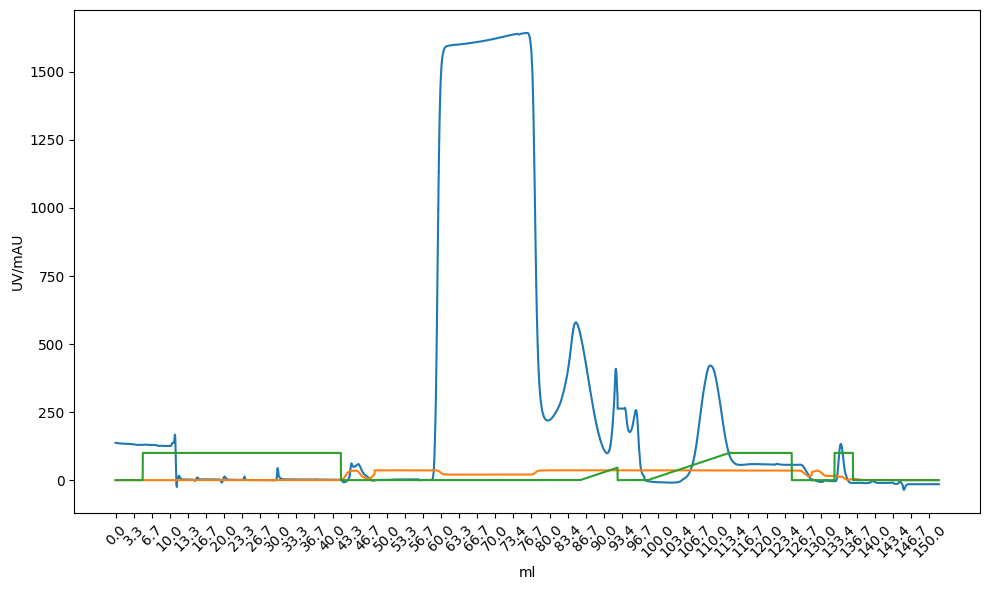

In [14]:
plt.figure(figsize=(10, 6))

plt.plot(merged_data.index, merged_data['UV(mAU)'], label='UV(mAU)')
plt.plot(merged_data.index, merged_data['Conductivity(mS/cm)'], label='Conductivity(mS/cm)')
plt.plot(merged_data.index, merged_data['%B'], label='%B')

plt.xlabel('ml')
plt.xticks(ticks=merged_data.index[::1000], rotation=45)
plt.ylabel('UV/mAU')
plt.tight_layout()
plt.savefig("./fig1.svg", format='svg')

plt.show()